In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [6]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [(filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
              (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
              (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# --- JITTER FIX ---
# Adding 1e-5 noise to prevent the "Spectral Initialisation" error
X_jittered = X + np.random.normal(0, 1e-5, X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_jittered)

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


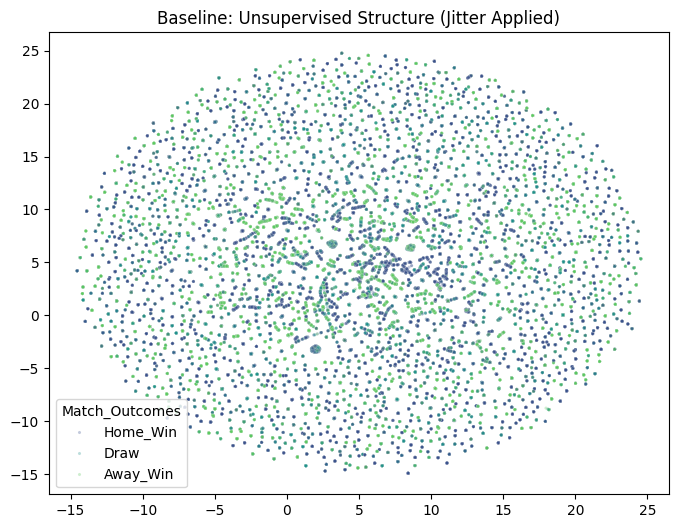

In [7]:
# STAGE 1: BASELINE
# =================================================================
print("--- Stage 1: Running Baseline ---")
# Using init='random' to avoid the spectral solver error
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=5, alpha=0.3, palette='viridis')
plt.title("Baseline: Unsupervised Structure (Jitter Applied)")
plt.show()


--- Stage 2: Supervised 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


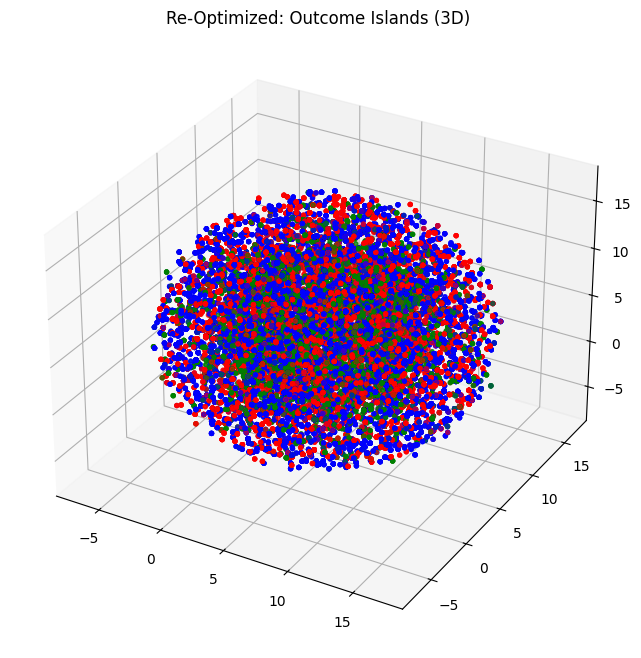

In [8]:
# STAGE 2: RE-OPTIMIZED (The Island Fix)
# =================================================================
print("\n--- Stage 2: Supervised 3D UMAP + HDBSCAN ---")

y_encoded = pd.factorize(y_true)[0]

# ADJUSTMENTS:
# n_neighbors=5 forces local clusters (islands)
# target_weight=0.95 forces outcome separation
# init='random' skips the failing math that caused your warning
reducer_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=5, 
    min_dist=0.0, 
    target_weight=0.95, 
    init='random', 
    random_state=42
)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

# HDBSCAN ADJUSTMENTS:
# Lower min_cluster_size helps find more specific tactical archetypes
clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=60, 
    min_samples=10, 
    cluster_selection_method='eom'
)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

# 3D Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': 'blue', 'Away_Win': 'red', 'Draw': 'green'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=8, alpha=0.5)
ax.set_title("Re-Optimized: Outcome Islands (3D)")
plt.show()


--- Stage 3: Readable Archetype Analysis ---


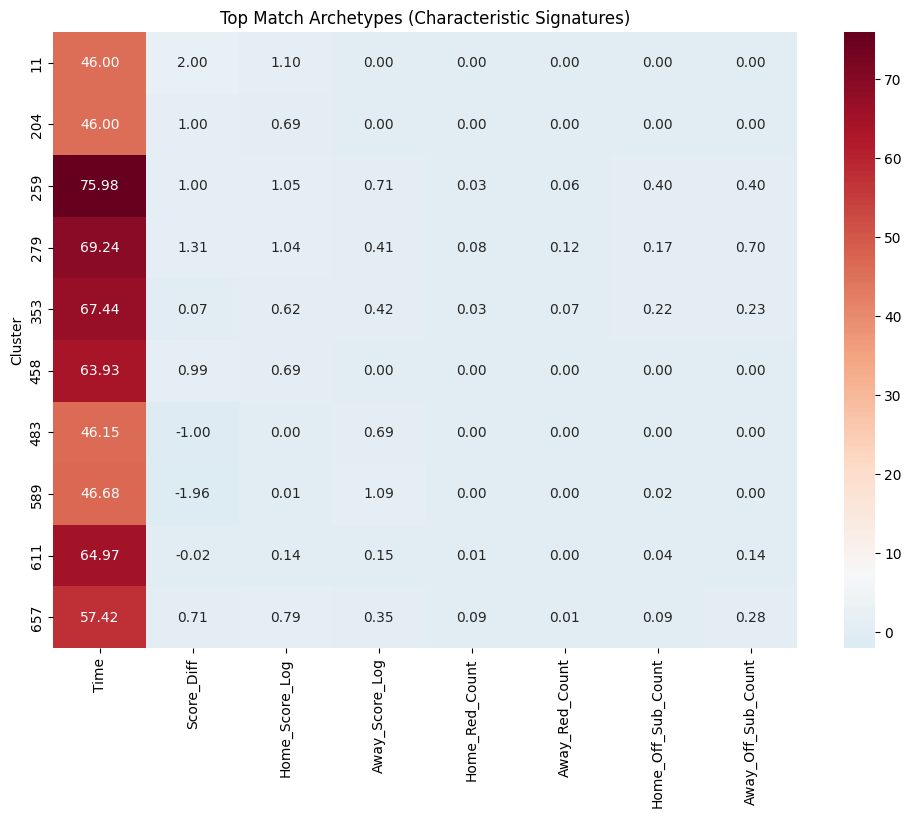

Cluster Dominance Breakdown:
Outcome  Away_Win      Draw  Home_Win
Cluster                              
204      0.111794  0.190418  0.697789
483      0.550000  0.218182  0.231818
11       0.072600  0.063232  0.864169
353      0.263285  0.193237  0.543478
589      0.753521  0.119718  0.126761
657      0.243816  0.212014  0.544170
259      0.230496  0.148936  0.620567
458      0.098361  0.213115  0.688525
611      0.257384  0.531646  0.210970
279      0.126582  0.042194  0.831224


In [9]:
# STAGE 3: FEATURE PROFILING
# =================================================================
print("\n--- Stage 3: Readable Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values

purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
pure_ids = purity.index[(purity.max(axis=1) > 0.5) & (purity.index != -1)]
top_pure_ids = analysis_df[analysis_df['Cluster'].isin(pure_ids)]['Cluster'].value_counts().iloc[:10].index
cluster_stats = analysis_df[analysis_df['Cluster'].isin(top_pure_ids)].groupby('Cluster').mean(numeric_only=True)

if not cluster_stats.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_stats, annot=True, fmt=".2f", cmap='RdBu_r', center=cluster_stats.values.mean())
    plt.title("Top Match Archetypes (Characteristic Signatures)")
    plt.show()
    print("Cluster Dominance Breakdown:")
    print(purity.loc[top_pure_ids])